# Benchmark 3: Heterogeneous density

- *Authors*: Danilo Aballay and Elwin van 't Wout
- *Affiliation*: Pontificia Universidad Católica de Chile
- *Date:* 26 May 2026
- *Description*: This benchmark considers a cubic scatterer with a heterogeneous material density. The numerical results from the VSIE and BEM are compared.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from benchmarks import VSIE_solve, bempp_solve
from parameters import PARAMETERS

INFO:bempp:Numba backend activated. For full performance the OpenCL backend with an OpenCL CPU driver is required.


In [ ]:
def matrix_linf_norm(vec, shape):
    return np.linalg.norm(np.real(vec).reshape(shape), ord=np.inf)

def run_benchmark(parameters, element_per_wavelength=8):
    pressure_vie, problem = VSIE_solve(element_per_wavelength, parameters)
    

    n_vox = round(problem.mesh.shape[0]**(1/3))
    points3D = problem.mesh.reshape((n_vox, n_vox, n_vox, 3))
    slice = points3D[:, :, n_vox//2, :]
    points = slice.reshape((-1, 3))
    pressure_vie3D = pressure_vie.reshape((n_vox, n_vox, n_vox))
    pressure_vie_slice = pressure_vie3D[:, :, n_vox//2].reshape((-1,))

    pressure_bempp =  bempp_solve(element_per_wavelength, parameters, points.T)

    error_bempp_l2 = np.linalg.norm(np.real(pressure_bempp))
    error_bempp_linf = matrix_linf_norm(pressure_bempp, (n_vox, n_vox))

    error_abs_l2 = np.linalg.norm(np.real(pressure_vie_slice) - np.real(pressure_bempp))
    error_abs_linf = matrix_linf_norm(np.real(pressure_vie_slice) - np.real(pressure_bempp), (n_vox, n_vox))


    error_rel_l2 = error_abs_l2 / error_bempp_l2
    error_rel_linf = error_abs_linf / error_bempp_linf

    data = {
        'solution_vie': pressure_vie_slice,
        'solution_bempp': pressure_bempp,
        'error_abs_l2': error_abs_l2,
        'error_abs_linf': error_abs_linf,
        'error_rel_l2': error_rel_l2,
        'error_rel_linf': error_rel_linf,
        'Nx': n_vox,
        'Ny': n_vox,
        'Nz': n_vox,
        'points': points,
    }

    return data

## Single benchmark

Let us perform a single benchmark with a fixed number of elements per wavelength.

In [ ]:
"""
Singular test
"""

data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=10)

INFO:bempp:Created grid with id 628abc48-655f-490b-b956-5042df5da5aa. Elements: 20172. Edges: 30258. Vertices: 10088
TIMING:bempp:Grid.__init__ : 2.185e+00s
TIMING:bempp:_compute_p1_dof_map : 9.350e-01s
TIMING:bempp:p1_continuous_function_space : 1.007e+00s
TIMING:bempp:_compute_p1_dof_map : 3.673e-03s
TIMING:bempp:p1_continuous_function_space : 2.999e-02s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.5819699764251709s
TIMING:bempp:assemble_sparse : 5.836e-01s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.005875110626220703s
TIMING:bempp:assemble_sparse : 7.053e-03s
TIMING:bempp:Start operation: Regular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Regular assembler:helmholtz_double_layer_boundary:numba: 34.79980516433716s
TIMING:bempp:Start operation: Singular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Singular assembler:helmholtz_double_layer_boundary:numba: 2.14768791

  cmap=plt.cm.get_cmap('seismic'),



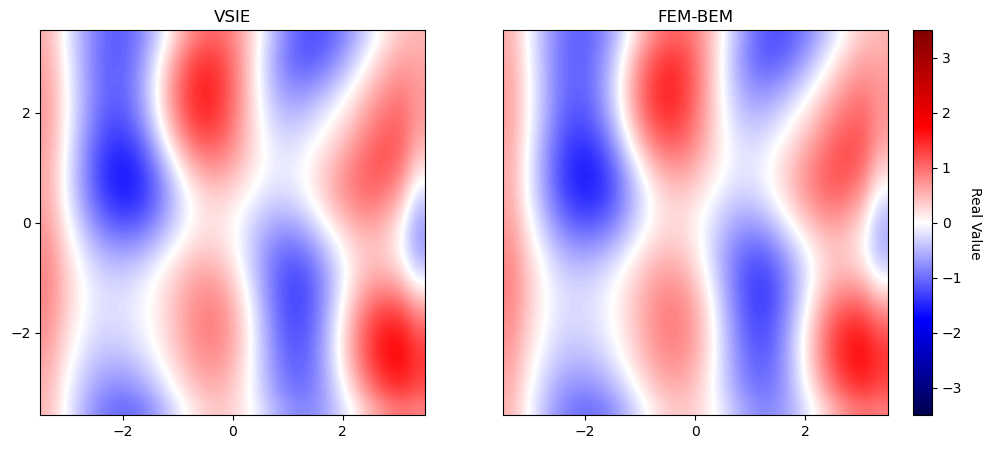

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(13,5))

xmin, xmax, ymin, ymax = -PARAMETERS["SIZE"]/2, PARAMETERS["SIZE"]/2, -PARAMETERS["SIZE"]/2, PARAMETERS["SIZE"]/2
l_cube = PARAMETERS["SIZE"]/2

Nx = data_benchmark['Nx']
Ny = data_benchmark['Ny']

bem_sol = data_benchmark['solution_bempp'].reshape((Nx, Ny))
vie_sol = data_benchmark['solution_vie'].reshape((Nx, Ny))

info_plot_re = [
    (axs[1], "FEM-BEM", np.real((bem_sol).T[::-1]), [-3.5, 3.5]),
    (axs[0], "VSIE", np.real((vie_sol).T[::-1]), [-3.5, 3.5]),
]


for (ax, title, data, clims) in info_plot_re:
    ax.set_title(title)
    im = ax.imshow(data,
              extent=[xmin*1e3, xmax*1e3, ymin*1e3, ymax*1e3],
              cmap=plt.cm.get_cmap('seismic'), 
              interpolation='spline16',
              clim=clims)
    ax.set_aspect('equal')

axs[1].get_yaxis().set_visible(False)
# axs[0].get_yaxis().

my_ticks = np.array([-2, 0, 2])

axs[0].set_xticks(my_ticks)
axs[1].set_xticks(my_ticks)
axs[0].set_yticks(my_ticks)
    
cbar = axs[1].figure.colorbar(im, ax=axs[1])
cbar.ax.set_ylabel('Real Value', rotation=-90, va="bottom")



plt.subplots_adjust(wspace=0, hspace=0)

In [5]:
print("Relative L2 error: ", data_benchmark['error_rel_l2'])
print("Relative Linf error: ", data_benchmark['error_rel_linf'])

Relative L2 error:  0.056350187003782755
Relative Linf error:  0.05755427827272545


## Convergence test

Let us perform a grid convergence test. Depending on computational resources, this may take minutes until hours. Eliminate or add experiments to the list of `elements_per_wavelength`.

In [ ]:
"""
Convergence test
"""

elements_per_wavelength = [5, 6, 7, 8, 9, 10, 11, 12]

data_convergence = defaultdict(list)

for element_per_wavelength in elements_per_wavelength:
    data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=element_per_wavelength)
    data_convergence['element_per_wavelength'].append(element_per_wavelength)
    data_convergence['N_elem'].append(data_benchmark['Nx'])
    data_convergence['error_rel_l2'].append(data_benchmark['error_rel_l2'])
    data_convergence['error_rel_linf'].append(data_benchmark['error_rel_linf'])
    print(f"Done with element_per_wavelength = {element_per_wavelength}")

INFO:bempp:Created grid with id 8021e817-5888-4cfd-88de-52d645e5daf2. Elements: 4800. Edges: 7200. Vertices: 2402
TIMING:bempp:Grid.__init__ : 1.451e-02s
TIMING:bempp:_compute_p1_dof_map : 8.891e-04s
TIMING:bempp:p1_continuous_function_space : 7.673e-03s
TIMING:bempp:_compute_p1_dof_map : 8.519e-04s
TIMING:bempp:p1_continuous_function_space : 8.357e-03s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.0014662742614746094s
TIMING:bempp:assemble_sparse : 2.321e-03s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.0012679100036621094s
TIMING:bempp:assemble_sparse : 1.996e-03s
TIMING:bempp:Start operation: Regular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Regular assembler:helmholtz_double_layer_boundary:numba: 1.6205718517303467s
TIMING:bempp:Start operation: Singular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Singular assembler:helmholtz_double_layer_boundary:numba: 0.165426

Done with points_per_element = 5


INFO:bempp:Created grid with id f42c2e12-03c4-467f-abd6-a6d0e44c10fc. Elements: 7500. Edges: 11250. Vertices: 3752
TIMING:bempp:Grid.__init__ : 2.316e-02s
TIMING:bempp:_compute_p1_dof_map : 1.492e-03s
TIMING:bempp:p1_continuous_function_space : 1.184e-02s
TIMING:bempp:_compute_p1_dof_map : 1.360e-03s
TIMING:bempp:p1_continuous_function_space : 1.238e-02s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.002070903778076172s
TIMING:bempp:assemble_sparse : 2.941e-03s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.0022649765014648438s
TIMING:bempp:assemble_sparse : 2.822e-03s
TIMING:bempp:Start operation: Regular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Regular assembler:helmholtz_double_layer_boundary:numba: 3.79803204536438s
TIMING:bempp:Start operation: Singular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Singular assembler:helmholtz_double_layer_boundary:numba: 0.24542975

Done with points_per_element = 6


INFO:bempp:Created grid with id 8d3d6c60-a734-4b32-8251-36bf4cff61aa. Elements: 10092. Edges: 15138. Vertices: 5048
TIMING:bempp:Grid.__init__ : 2.876e-02s
TIMING:bempp:_compute_p1_dof_map : 1.874e-03s
TIMING:bempp:p1_continuous_function_space : 1.568e-02s
TIMING:bempp:_compute_p1_dof_map : 1.797e-03s
TIMING:bempp:p1_continuous_function_space : 7.493e-02s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.0025069713592529297s
TIMING:bempp:assemble_sparse : 3.500e-03s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.00286102294921875s
TIMING:bempp:assemble_sparse : 3.591e-03s
TIMING:bempp:Start operation: Regular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Regular assembler:helmholtz_double_layer_boundary:numba: 7.21129298210144s
TIMING:bempp:Start operation: Singular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Singular assembler:helmholtz_double_layer_boundary:numba: 0.43528699

...

Done with points_per_element = 10


INFO:bempp:Created grid with id 55dfb9e7-4bb5-4d43-81b1-4304e594ea86. Elements: 25392. Edges: 38088. Vertices: 12698
TIMING:bempp:Grid.__init__ : 7.299e-02s
TIMING:bempp:_compute_p1_dof_map : 4.597e-03s
TIMING:bempp:p1_continuous_function_space : 1.007e-01s
TIMING:bempp:_compute_p1_dof_map : 4.601e-03s
TIMING:bempp:p1_continuous_function_space : 8.858e-02s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.006877899169921875s
TIMING:bempp:assemble_sparse : 8.478e-03s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.007231235504150391s
TIMING:bempp:assemble_sparse : 8.889e-03s
TIMING:bempp:Start operation: Regular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Regular assembler:helmholtz_double_layer_boundary:numba: 55.170721769332886s
TIMING:bempp:Start operation: Singular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Singular assembler:helmholtz_double_layer_boundary:numba: 1.00393

Done with points_per_element = 11


INFO:bempp:Created grid with id 47e5ef54-26f5-4491-b98b-135816410096. Elements: 30000. Edges: 45000. Vertices: 15002
TIMING:bempp:Grid.__init__ : 8.581e-02s
TIMING:bempp:_compute_p1_dof_map : 5.622e-03s
TIMING:bempp:p1_continuous_function_space : 1.080e-01s
TIMING:bempp:_compute_p1_dof_map : 5.472e-03s
TIMING:bempp:p1_continuous_function_space : 1.009e-01s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.007361888885498047s
TIMING:bempp:assemble_sparse : 9.359e-03s
TIMING:bempp:Start operation: 
TIMING:bempp:Finished Operation: : 0.008966207504272461s
TIMING:bempp:assemble_sparse : 1.085e-02s
TIMING:bempp:Start operation: Regular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Regular assembler:helmholtz_double_layer_boundary:numba: 86.66183018684387s
TIMING:bempp:Start operation: Singular assembler:helmholtz_double_layer_boundary:numba
TIMING:bempp:Finished Operation: Singular assembler:helmholtz_double_layer_boundary:numba: 1.258652

Done with points_per_element = 12


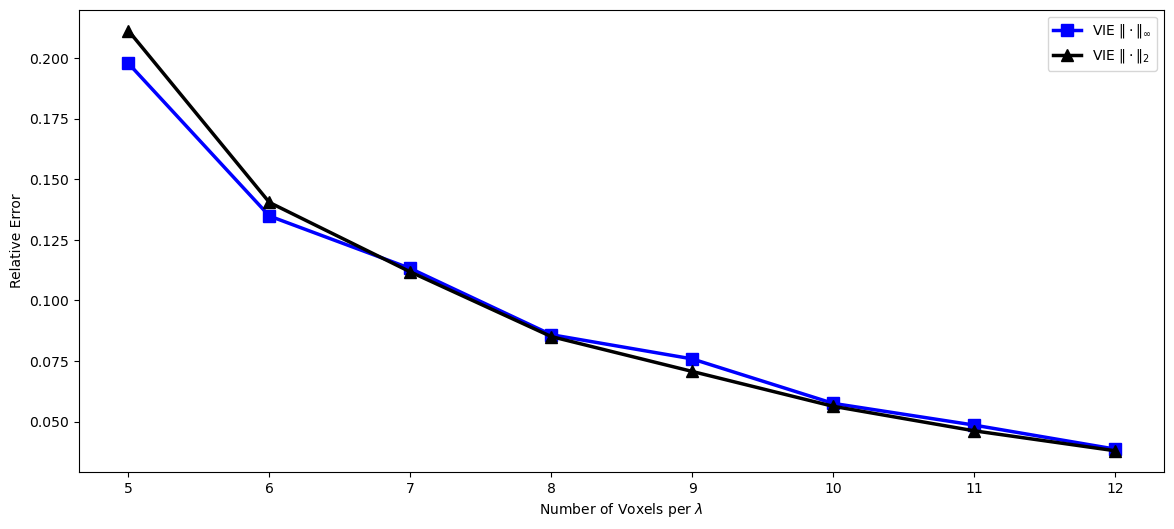

In [ ]:
from matplotlib.ticker import MaxNLocator

num_vox = data_convergence['element_per_wavelength']
inf_err = data_convergence['error_rel_linf']
frb_err = data_convergence['error_rel_l2']


ax = plt.figure(figsize=(14, 6)).gca()

ax.plot(num_vox, inf_err, 'bs-', label='VIE $\|\cdot\|_\infty$', linewidth=2.5, markersize=8)
ax.plot(num_vox, frb_err, 'k^-', label='VIE $\|\cdot\|_2$', linewidth=2.5, markersize=8)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel(r'Number of Voxels per $\lambda$')
plt.ylabel('Relative Error')
plt.legend()

plt.show()

## Visualize convergence from data

The convergence test was performed on a powerful compute node and the results stored in the `data` folder. Let us load them and visualize the convergence plot.

In [2]:
"""
Convergence Plot from data
"""

num_vox = []
frb_err = []
inf_err = []


for i in range(5, 20):
    try:
        data_benchmark = np.load(f"data/benchmark_num_elem_{i}.npy", allow_pickle=True).item()
        num_vox.append(data_benchmark['num_elem'])
        frb_err.append(data_benchmark['error_rel_l2'])
        inf_err.append(data_benchmark['error_rel_linf'])
    except FileNotFoundError:
        print(f"File for N_elem={i} not found, skipping.")

num_vox = np.array(num_vox)
frb_err = np.array(frb_err)
inf_err = np.array(inf_err)

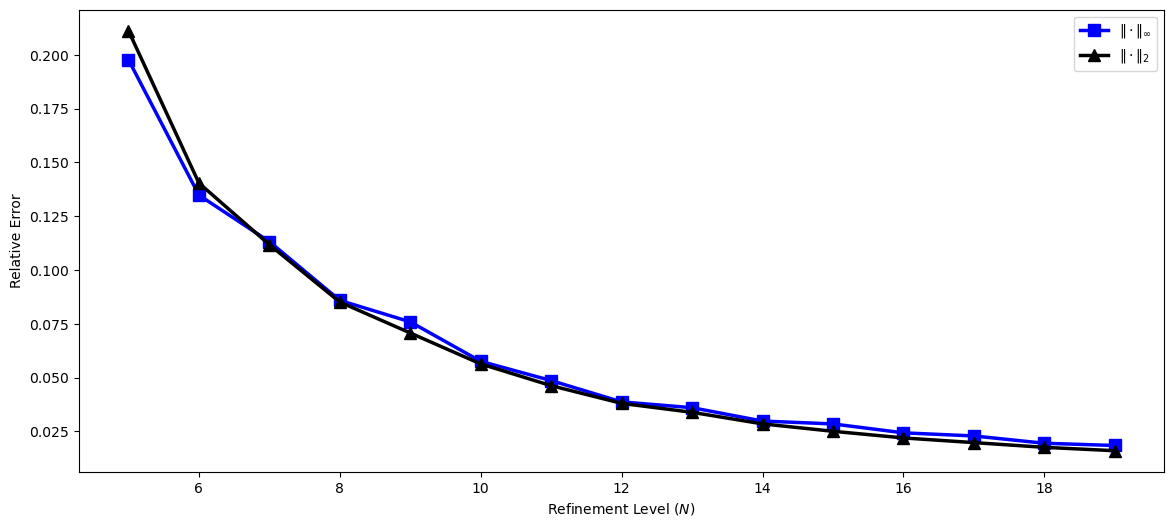

In [3]:

ax = plt.figure(figsize=(14, 6)).gca()

ax.plot(num_vox, inf_err, 'bs-', label=r'$\|\cdot\|_\infty$', linewidth=2.5, markersize=8)
ax.plot(num_vox, frb_err, 'k^-', label=r'$\|\cdot\|_2$', linewidth=2.5, markersize=8)

from matplotlib.ticker import MaxNLocator

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel(r'Refinement Level $(N)$')
plt.ylabel('Relative Error')
plt.legend()


plt.show()